# 02 Feature Engineering
## ML Role
Feature engineering engine pipeline.
Applies transformations to raw continuous numerical variables for machine learning stability.
Includes logic defining:
- Temporal lag calculations: e.g., shift(24) for daily seasonality, shift(168) for weekly limits
- Cyclical encoding: sin/cos transformations for hour, day, month (preserves temporal boundary circular distance)
- Rolling window statistics: mean/std over 24h, 72h, 168h windows for trend detection\n

In [1]:
"""
FEATURE ENGINEERING FOR SPAIN ENERGY FORECASTING
================================================
This notebook creates advanced features for time-series prediction.

Target: Predict consumption and price for next 24 hours
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("=" * 80)
print("FEATURE ENGINEERING - SPAIN ENERGY FORECASTING".center(80))
print("=" * 80)
print(f"\nStarted: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

                 FEATURE ENGINEERING - SPAIN ENERGY FORECASTING                 

Started: 2026-04-13 18:49:03



In [2]:
# Load the cleaned merged dataset
print("=" * 80)
print("LOADING CLEANED DATA")
print("=" * 80)

df = pd.read_csv('data/processed/processed.csv', 
                 parse_dates=['datetime'], 
                 index_col='datetime')

print(f"\n✓ Data loaded successfully")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range: {df.index.min()} to {df.index.max()}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n✓ Columns in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

LOADING CLEANED DATA

✓ Data loaded successfully
  Shape: 98,895 rows × 32 columns
  Date range: 2014-12-31 23:00:00+00:00 to 2026-04-13 23:00:00+02:00
  Memory usage: 36.22 MB

✓ Columns in dataset:
   1. consumption_mw
   2. price_eur_mwh
   3. load_forecast_mw
   4. price_day_ahead_eur
   5. gen_solar_mw
   6. gen_wind_onshore_mw
   7. gen_wind_offshore_mw
   8. gen_hydro_ror_mw
   9. gen_nuclear_mw
  10. gen_fossil_gas_mw
  11. forecast_solar_mw
  12. forecast_wind_onshore_mw
  13. temperature_celsius
  14. temp_min_celsius
  15. temp_max_celsius
  16. pressure_hpa
  17. humidity_percent
  18. wind_speed_ms
  19. wind_direction_deg
  20. rain_mm
  21. cloud_cover_percent
  22. year
  23. month
  24. day
  25. hour
  26. dayofweek
  27. is_weekend
  28. quarter
  29. hour_sin
  30. hour_cos
  31. month_sin
  32. month_cos


In [3]:
print("\n" + "=" * 80)
print("CREATING LAG FEATURES")
print("=" * 80)

# Define lag periods (in hours)
LAG_PERIODS = [1, 2, 3, 6, 12, 24, 48, 168]  # 1h, 2h, 3h, 6h, 12h, 1d, 2d, 1w

print(f"\nCreating lags for periods: {LAG_PERIODS}")

# Consumption lag features
print("\n1. Consumption lag features...")
for lag in LAG_PERIODS:
    col_name = f'consumption_lag_{lag}h'
    df[col_name] = df['consumption_mw'].shift(lag)
    print(f"  ✓ Created: {col_name}")

# Price lag features
print("\n2. Price lag features...")
for lag in LAG_PERIODS:
    col_name = f'price_lag_{lag}h'
    df[col_name] = df['price_eur_mwh'].shift(lag)
    print(f"  ✓ Created: {col_name}")

# Temperature lag features (useful for consumption prediction)
print("\n3. Temperature lag features...")
for lag in [1, 24]:  # Just 1h and 24h for temperature
    col_name = f'temp_lag_{lag}h'
    df[col_name] = df['temperature_celsius'].shift(lag)
    print(f"  ✓ Created: {col_name}")

lag_feature_count = len(LAG_PERIODS) * 2 + 2  # consumption + price + temp
print(f"\n✓ Total lag features created: {lag_feature_count}")


CREATING LAG FEATURES

Creating lags for periods: [1, 2, 3, 6, 12, 24, 48, 168]

1. Consumption lag features...
  ✓ Created: consumption_lag_1h
  ✓ Created: consumption_lag_2h
  ✓ Created: consumption_lag_3h
  ✓ Created: consumption_lag_6h
  ✓ Created: consumption_lag_12h
  ✓ Created: consumption_lag_24h
  ✓ Created: consumption_lag_48h
  ✓ Created: consumption_lag_168h

2. Price lag features...
  ✓ Created: price_lag_1h
  ✓ Created: price_lag_2h
  ✓ Created: price_lag_3h
  ✓ Created: price_lag_6h
  ✓ Created: price_lag_12h
  ✓ Created: price_lag_24h
  ✓ Created: price_lag_48h
  ✓ Created: price_lag_168h

3. Temperature lag features...
  ✓ Created: temp_lag_1h
  ✓ Created: temp_lag_24h

✓ Total lag features created: 18


In [4]:
print("\n" + "=" * 80)
print("CREATING ROLLING STATISTICS FEATURES")
print("=" * 80)

# Define rolling windows (in hours)
ROLLING_WINDOWS = [24, 72, 168]  # 1 day, 3 days, 1 week

print(f"\nCreating rolling statistics for windows: {ROLLING_WINDOWS}")

rolling_count = 0

# Consumption rolling features
print("\n1. Consumption rolling statistics...")
for window in ROLLING_WINDOWS:
    # Mean
    col_name = f'consumption_rolling_mean_{window}h'
    df[col_name] = df['consumption_mw'].shift(1).rolling(window).mean()
    print(f"  ✓ Created: {col_name}")
    rolling_count += 1
    
    # Standard deviation
    col_name = f'consumption_rolling_std_{window}h'
    df[col_name] = df['consumption_mw'].shift(1).rolling(window).std()
    print(f"  ✓ Created: {col_name}")
    rolling_count += 1
    
    # Min and Max (only for 24h window to avoid too many features)
    if window == 24:
        col_name = f'consumption_rolling_min_{window}h'
        df[col_name] = df['consumption_mw'].shift(1).rolling(window).min()
        print(f"  ✓ Created: {col_name}")
        rolling_count += 1
        
        col_name = f'consumption_rolling_max_{window}h'
        df[col_name] = df['consumption_mw'].shift(1).rolling(window).max()
        print(f"  ✓ Created: {col_name}")
        rolling_count += 1

# Price rolling features
print("\n2. Price rolling statistics...")
for window in ROLLING_WINDOWS:
    # Mean
    col_name = f'price_rolling_mean_{window}h'
    df[col_name] = df['price_eur_mwh'].shift(1).rolling(window).mean()
    print(f"  ✓ Created: {col_name}")
    rolling_count += 1
    
    # Standard deviation (volatility)
    col_name = f'price_rolling_std_{window}h'
    df[col_name] = df['price_eur_mwh'].shift(1).rolling(window).std()
    print(f"  ✓ Created: {col_name}")
    rolling_count += 1

# Temperature rolling features
print("\n3. Temperature rolling statistics...")
for window in [24, 168]:
    col_name = f'temp_rolling_mean_{window}h'
    df[col_name] = df['temperature_celsius'].shift(1).rolling(window).mean()
    print(f"  ✓ Created: {col_name}")
    rolling_count += 1

print(f"\n✓ Total rolling features created: {rolling_count}")


CREATING ROLLING STATISTICS FEATURES

Creating rolling statistics for windows: [24, 72, 168]

1. Consumption rolling statistics...
  ✓ Created: consumption_rolling_mean_24h
  ✓ Created: consumption_rolling_std_24h
  ✓ Created: consumption_rolling_min_24h
  ✓ Created: consumption_rolling_max_24h
  ✓ Created: consumption_rolling_mean_72h
  ✓ Created: consumption_rolling_std_72h
  ✓ Created: consumption_rolling_mean_168h
  ✓ Created: consumption_rolling_std_168h

2. Price rolling statistics...
  ✓ Created: price_rolling_mean_24h
  ✓ Created: price_rolling_std_24h
  ✓ Created: price_rolling_mean_72h
  ✓ Created: price_rolling_std_72h
  ✓ Created: price_rolling_mean_168h
  ✓ Created: price_rolling_std_168h

3. Temperature rolling statistics...
  ✓ Created: temp_rolling_mean_24h
  ✓ Created: temp_rolling_mean_168h

✓ Total rolling features created: 16


In [5]:
print("\n" + "=" * 80)
print("CREATING DERIVED FEATURES")
print("=" * 80)

derived_count = 0

# 1. Difference features (rate of change)
print("\n1. Difference features (rate of change)...")

df['consumption_diff_1h'] = df['consumption_mw'] - df['consumption_mw'].shift(1)
print(f"  ✓ Created: consumption_diff_1h")
derived_count += 1

df['consumption_diff_24h'] = df['consumption_mw'] - df['consumption_mw'].shift(24)
print(f"  ✓ Created: consumption_diff_24h")
derived_count += 1

df['price_diff_1h'] = df['price_eur_mwh'] - df['price_eur_mwh'].shift(1)
print(f"  ✓ Created: price_diff_1h")
derived_count += 1

df['price_diff_24h'] = df['price_eur_mwh'] - df['price_eur_mwh'].shift(24)
print(f"  ✓ Created: price_diff_24h")
derived_count += 1

# 2. Percentage change features
print("\n2. Percentage change features...")

df['consumption_pct_change_24h'] = df['consumption_mw'].pct_change(24) * 100
print(f"  ✓ Created: consumption_pct_change_24h")
derived_count += 1

df['price_pct_change_24h'] = df['price_eur_mwh'].pct_change(24) * 100
print(f"  ✓ Created: price_pct_change_24h")
derived_count += 1

# 3. Interaction features
print("\n3. Interaction features...")

df['temp_consumption_interaction'] = df['temperature_celsius'] * df['consumption_mw'] / 1000
print(f"  ✓ Created: temp_consumption_interaction")
derived_count += 1

# Total renewable generation
if 'gen_solar_mw' in df.columns and 'gen_wind_onshore_mw' in df.columns:
    df['total_renewable_mw'] = (df['gen_solar_mw'].fillna(0) + 
                                 df['gen_wind_onshore_mw'].fillna(0) + 
                                 df.get('gen_wind_offshore_mw', 0).fillna(0))
    print(f"  ✓ Created: total_renewable_mw")
    derived_count += 1

# Renewable percentage
if 'total_renewable_mw' in df.columns:
    df['renewable_percentage'] = (df['total_renewable_mw'] / df['consumption_mw']) * 100
    print(f"  ✓ Created: renewable_percentage")
    derived_count += 1

# 4. Hour type features
print("\n4. Hour type features...")

df['is_peak_hour'] = ((df['hour'] >= 9) & (df['hour'] <= 21)).astype(int)
print(f"  ✓ Created: is_peak_hour (9am-9pm)")
derived_count += 1

df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
print(f"  ✓ Created: is_night (midnight-6am)")
derived_count += 1

# 5. Season feature
print("\n5. Season feature...")

def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df['season'] = df['month'].apply(get_season)
print(f"  ✓ Created: season (0=Winter, 1=Spring, 2=Summer, 3=Autumn)")
derived_count += 1

print(f"\n✓ Total derived features created: {derived_count}")


CREATING DERIVED FEATURES

1. Difference features (rate of change)...
  ✓ Created: consumption_diff_1h
  ✓ Created: consumption_diff_24h
  ✓ Created: price_diff_1h
  ✓ Created: price_diff_24h

2. Percentage change features...
  ✓ Created: consumption_pct_change_24h
  ✓ Created: price_pct_change_24h

3. Interaction features...
  ✓ Created: temp_consumption_interaction
  ✓ Created: total_renewable_mw
  ✓ Created: renewable_percentage

4. Hour type features...
  ✓ Created: is_peak_hour (9am-9pm)
  ✓ Created: is_night (midnight-6am)

5. Season feature...
  ✓ Created: season (0=Winter, 1=Spring, 2=Summer, 3=Autumn)

✓ Total derived features created: 12


In [6]:
print("\n" + "=" * 80)
print("CREATING CYCLICAL ENCODING FEATURES")
print("=" * 80)

cyclical_count = 0

# Hour encoding (24-hour cycle)
print("\n1. Hour cyclical encoding...")
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
print(f"  ✓ Created: hour_sin, hour_cos")
cyclical_count += 2

# Day of week encoding (7-day cycle)
print("\n2. Day of week cyclical encoding...")
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
print(f"  ✓ Created: dayofweek_sin, dayofweek_cos")
cyclical_count += 2

# Month encoding (12-month cycle)
print("\n3. Month cyclical encoding...")
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
print(f"  ✓ Created: month_sin, month_cos")
cyclical_count += 2

# Day of month encoding (approximate 30-day cycle)
print("\n4. Day of month cyclical encoding...")
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 30)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 30)
print(f"  ✓ Created: day_sin, day_cos")
cyclical_count += 2

print(f"\n✓ Total cyclical features created: {cyclical_count}")


CREATING CYCLICAL ENCODING FEATURES

1. Hour cyclical encoding...
  ✓ Created: hour_sin, hour_cos

2. Day of week cyclical encoding...
  ✓ Created: dayofweek_sin, dayofweek_cos

3. Month cyclical encoding...
  ✓ Created: month_sin, month_cos

4. Day of month cyclical encoding...
  ✓ Created: day_sin, day_cos

✓ Total cyclical features created: 8


In [7]:
print("\n" + "=" * 80)
print("CREATING TARGET VARIABLES (24-HOUR AHEAD)")
print("=" * 80)

target_count = 0

# Consumption targets
print("\n1. Creating consumption targets (h+1 to h+24)...")
for h in range(1, 25):
    col_name = f'target_consumption_h{h}'
    df[col_name] = df['consumption_mw'].shift(-h)
    target_count += 1
print(f"  ✓ Created {target_count} consumption targets")

# Price targets
print("\n2. Creating price targets (h+1 to h+24)...")
target_start = target_count
for h in range(1, 25):
    col_name = f'target_price_h{h}'
    df[col_name] = df['price_eur_mwh'].shift(-h)
    target_count += 1
print(f"  ✓ Created {target_count - target_start} price targets")

print(f"\n✓ Total target variables created: {target_count}")


CREATING TARGET VARIABLES (24-HOUR AHEAD)

1. Creating consumption targets (h+1 to h+24)...
  ✓ Created 24 consumption targets

2. Creating price targets (h+1 to h+24)...
  ✓ Created 24 price targets

✓ Total target variables created: 48


In [12]:
print("\n" + "=" * 80)
print("FEATURE SUMMARY")
print("=" * 80)

print(f"\nDataset shape after feature engineering: {df.shape}")

# Categorize features
original_features = 32  # From cleaned data
lag_features = [col for col in df.columns if 'lag' in col]
rolling_features = [col for col in df.columns if 'rolling' in col]
derived_features = [col for col in df.columns if any(x in col for x in ['diff', 'pct_change', 'interaction', 'renewable', 'peak', 'night', 'season'])]
cyclical_features = [col for col in df.columns if any(x in col for x in ['_sin', '_cos'])]
target_features = [col for col in df.columns if 'target' in col]

print(f"\n📊 Feature Categories:")
print(f"  Original features: {original_features}")
print(f"  Lag features: {len(lag_features)}")
print(f"  Rolling statistics: {len(rolling_features)}")
print(f"  Derived features: {len(derived_features)}")
print(f"  Cyclical encoding: {len(cyclical_features)}")
print(f"  Target variables: {len(target_features)}")
print(f"  " + "-" * 40)
print(f"  TOTAL COLUMNS: {df.shape[1]}")

# Check for missing values
print(f"\n📊 Missing Values Check:")
missing_count = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_pct = (missing_count / total_cells) * 100
print(f"  Total missing values: {missing_count:,} ({missing_pct:.2f}%)")


FEATURE SUMMARY

Dataset shape after feature engineering: (98453, 130)

📊 Feature Categories:
  Original features: 32
  Lag features: 18
  Rolling statistics: 16
  Derived features: 12
  Cyclical encoding: 8
  Target variables: 48
  ----------------------------------------
  TOTAL COLUMNS: 130

📊 Missing Values Check:
  Total missing values: 0 (0.00%)


In [10]:
print("\n" + "=" * 80)
print("CLEANING DATA - REMOVING NaN VALUES")
print("=" * 80)

print(f"\nBefore cleaning:")
print(f"  Rows: {len(df):,}")

# Remove rows with any NaN values
df_clean = df.dropna()

rows_dropped = len(df) - len(df_clean)

print(f"\nAfter cleaning:")
print(f"  Rows: {len(df_clean):,}")
print(f"  Rows dropped: {rows_dropped:,} ({rows_dropped/len(df)*100:.2f}%)")

print(f"\n✓ Clean dataset ready for modeling")
print(f"  Shape: {df_clean.shape}")
print(f"  Date range: {df_clean.index.min()} to {df_clean.index.max()}")

# Update df to clean version
df = df_clean


CLEANING DATA - REMOVING NaN VALUES

Before cleaning:
  Rows: 98,453

After cleaning:
  Rows: 98,453
  Rows dropped: 0 (0.00%)

✓ Clean dataset ready for modeling
  Shape: (98453, 130)
  Date range: 2015-01-08 02:00:00+00:00 to 2026-04-12 23:00:00+02:00


In [19]:
df.index = pd.to_datetime(df.index, utc=True)

In [20]:
df.index = df.index.tz_convert(None)

In [21]:
print("\n" + "=" * 80)
print("SPLITTING DATA: TRAIN / VALIDATION / TEST")
print("=" * 80)



TRAIN_END = pd.Timestamp('2024-12-31 23:00:00')
VAL_END = pd.Timestamp('2025-12-31 23:00:00')

train = df.loc[:TRAIN_END]
val = df.loc[(df.index > TRAIN_END) & (df.index <= VAL_END)]
test = df.loc[df.index > VAL_END]
print(f"\n📊 Data Split Summary:")

print(f"\n  TRAIN SET:")
print(f"    Rows: {len(train):,}")
print(f"    Date range: {train.index.min()} to {train.index.max()}")
print(f"    Percentage: {len(train)/len(df)*100:.1f}%")

print(f"\n  VALIDATION SET:")
print(f"    Rows: {len(val):,}")
print(f"    Date range: {val.index.min()} to {val.index.max()}")
print(f"    Percentage: {len(val)/len(df)*100:.1f}%")

print(f"\n  TEST SET:")
print(f"    Rows: {len(test):,}")
print(f"    Date range: {test.index.min()} to {test.index.max()}")
print(f"    Percentage: {len(test)/len(df)*100:.1f}%")

print(f"\n✓ Data split successfully")


SPLITTING DATA: TRAIN / VALIDATION / TEST

📊 Data Split Summary:

  TRAIN SET:
    Rows: 87,311
    Date range: 2015-01-08 02:00:00 to 2024-12-31 23:00:00
    Percentage: 88.7%

  VALIDATION SET:
    Rows: 8,730
    Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00
    Percentage: 8.9%

  TEST SET:
    Rows: 2,412
    Date range: 2026-01-01 00:00:00 to 2026-04-12 21:00:00
    Percentage: 2.4%

✓ Data split successfully


In [22]:
print("\n" + "=" * 80)
print("SPLITTING DATA: TRAIN / VALIDATION / TEST")
print("=" * 80)

import pandas as pd

# Define split dates (FIXED)
TRAIN_END = pd.Timestamp('2024-12-31 23:00:00').tz_localize(df.index.tz)
VAL_END = pd.Timestamp('2025-12-31 23:00:00').tz_localize(df.index.tz)
# Split
train = df.loc[:TRAIN_END].copy()
val = df.loc[(df.index > TRAIN_END) & (df.index <= VAL_END)].copy()
test = df.loc[df.index > VAL_END].copy()
print(f"\n📊 Data Split Summary:")

print(f"\n  TRAIN SET:")
print(f"    Rows: {len(train):,}")
print(f"    Date range: {train.index.min()} to {train.index.max()}")
print(f"    Percentage: {len(train)/len(df)*100:.1f}%")

print(f"\n  VALIDATION SET:")
print(f"    Rows: {len(val):,}")
print(f"    Date range: {val.index.min()} to {val.index.max()}")
print(f"    Percentage: {len(val)/len(df)*100:.1f}%")

print(f"\n  TEST SET:")
print(f"    Rows: {len(test):,}")
print(f"    Date range: {test.index.min()} to {test.index.max()}")
print(f"    Percentage: {len(test)/len(df)*100:.1f}%")

print(f"\n✓ Data split successfully")


SPLITTING DATA: TRAIN / VALIDATION / TEST

📊 Data Split Summary:

  TRAIN SET:
    Rows: 87,311
    Date range: 2015-01-08 02:00:00 to 2024-12-31 23:00:00
    Percentage: 88.7%

  VALIDATION SET:
    Rows: 8,730
    Date range: 2025-01-01 00:00:00 to 2025-12-31 23:00:00
    Percentage: 8.9%

  TEST SET:
    Rows: 2,412
    Date range: 2026-01-01 00:00:00 to 2026-04-12 21:00:00
    Percentage: 2.4%

✓ Data split successfully


In [23]:
print("\n" + "=" * 80)
print("SAVING FEATURE DATASETS")
print("=" * 80)

import os

# Create features directory if it doesn't exist
os.makedirs('data/features', exist_ok=True)

# Save train set
train_path = 'data/features/spain_features_train.csv'
train.to_csv(train_path)
train_size_mb = os.path.getsize(train_path) / (1024 * 1024)
print(f"\n✓ Train set saved:")
print(f"  Path: {train_path}")
print(f"  Size: {train_size_mb:.2f} MB")

# Save validation set
val_path = 'data/features/spain_features_val.csv'
val.to_csv(val_path)
val_size_mb = os.path.getsize(val_path) / (1024 * 1024)
print(f"\n✓ Validation set saved:")
print(f"  Path: {val_path}")
print(f"  Size: {val_size_mb:.2f} MB")

# Save test set
test_path = 'data/features/spain_features_test.csv'
test.to_csv(test_path)
test_size_mb = os.path.getsize(test_path) / (1024 * 1024)
print(f"\n✓ Test set saved:")
print(f"  Path: {test_path}")
print(f"  Size: {test_size_mb:.2f} MB")

print(f"\n✓ Total file size: {train_size_mb + val_size_mb + test_size_mb:.2f} MB")


SAVING FEATURE DATASETS

✓ Train set saved:
  Path: data/features/spain_features_train.csv
  Size: 100.39 MB

✓ Validation set saved:
  Path: data/features/spain_features_val.csv
  Size: 9.99 MB

✓ Test set saved:
  Path: data/features/spain_features_test.csv
  Size: 2.73 MB

✓ Total file size: 113.11 MB


In [24]:
print("\n" + "=" * 80)
print("CREATING FEATURE DOCUMENTATION")
print("=" * 80)

# Categorize all features
feature_categories = {
    'Original Features': [],
    'Lag Features': [],
    'Rolling Statistics': [],
    'Derived Features': [],
    'Cyclical Encoding': [],
    'Target Variables (Consumption)': [],
    'Target Variables (Price)': []
}

for col in df.columns:
    if 'target_consumption' in col:
        feature_categories['Target Variables (Consumption)'].append(col)
    elif 'target_price' in col:
        feature_categories['Target Variables (Price)'].append(col)
    elif 'lag' in col:
        feature_categories['Lag Features'].append(col)
    elif 'rolling' in col:
        feature_categories['Rolling Statistics'].append(col)
    elif any(x in col for x in ['_sin', '_cos']):
        feature_categories['Cyclical Encoding'].append(col)
    elif any(x in col for x in ['diff', 'pct_change', 'interaction', 'renewable', 'peak', 'night', 'season']):
        feature_categories['Derived Features'].append(col)
    else:
        feature_categories['Original Features'].append(col)

# Write to file
doc_path = 'data/features/feature_list.txt'

with open(doc_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("FEATURE ENGINEERING DOCUMENTATION\n")
    f.write("SPAIN ENERGY FORECASTING PROJECT\n")
    f.write("=" * 80 + "\n\n")
    
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Features: {df.shape[1]}\n")
    f.write(f"Total Rows (after cleaning): {len(df):,}\n\n")
    
    f.write("=" * 80 + "\n")
    f.write("DATASET SPLIT\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Train: {len(train):,} rows ({train.index.min()} to {train.index.max()})\n")
    f.write(f"Validation: {len(val):,} rows ({val.index.min()} to {val.index.max()})\n")
    f.write(f"Test: {len(test):,} rows ({test.index.min()} to {test.index.max()})\n\n")
    
    for category, features in feature_categories.items():
        f.write("=" * 80 + "\n")
        f.write(f"{category} ({len(features)} features)\n")
        f.write("=" * 80 + "\n\n")
        
        for i, feature in enumerate(sorted(features), 1):
            f.write(f"  {i:3d}. {feature}\n")
        f.write("\n")
    
    f.write("=" * 80 + "\n")
    f.write("FEATURE DESCRIPTIONS\n")
    f.write("=" * 80 + "\n\n")
    
    descriptions = {
        'Lag Features': 'Historical values at specific time offsets (1h, 2h, 24h, 168h, etc.)',
        'Rolling Statistics': 'Moving averages, std dev, min, max over time windows',
        'Derived Features': 'Rate of change, percentage change, interactions, and custom indicators',
        'Cyclical Encoding': 'Sin/cos transformation of cyclical time features (hour, day, month)',
        'Target Variables': 'Future values to predict (h+1 to h+24)'
    }
    
    for category, desc in descriptions.items():
        f.write(f"{category}:\n")
        f.write(f"  {desc}\n\n")

print(f"✓ Feature documentation saved to: {doc_path}")

# Print preview
print(f"\n📄 Feature List Preview:")
for category, features in feature_categories.items():
    print(f"\n  {category}: {len(features)} features")


CREATING FEATURE DOCUMENTATION
✓ Feature documentation saved to: data/features/feature_list.txt

📄 Feature List Preview:

  Original Features: 28 features

  Lag Features: 18 features

  Rolling Statistics: 16 features

  Derived Features: 12 features

  Cyclical Encoding: 8 features

  Target Variables (Consumption): 24 features

  Target Variables (Price): 24 features



VISUALIZING FEATURE CORRELATIONS


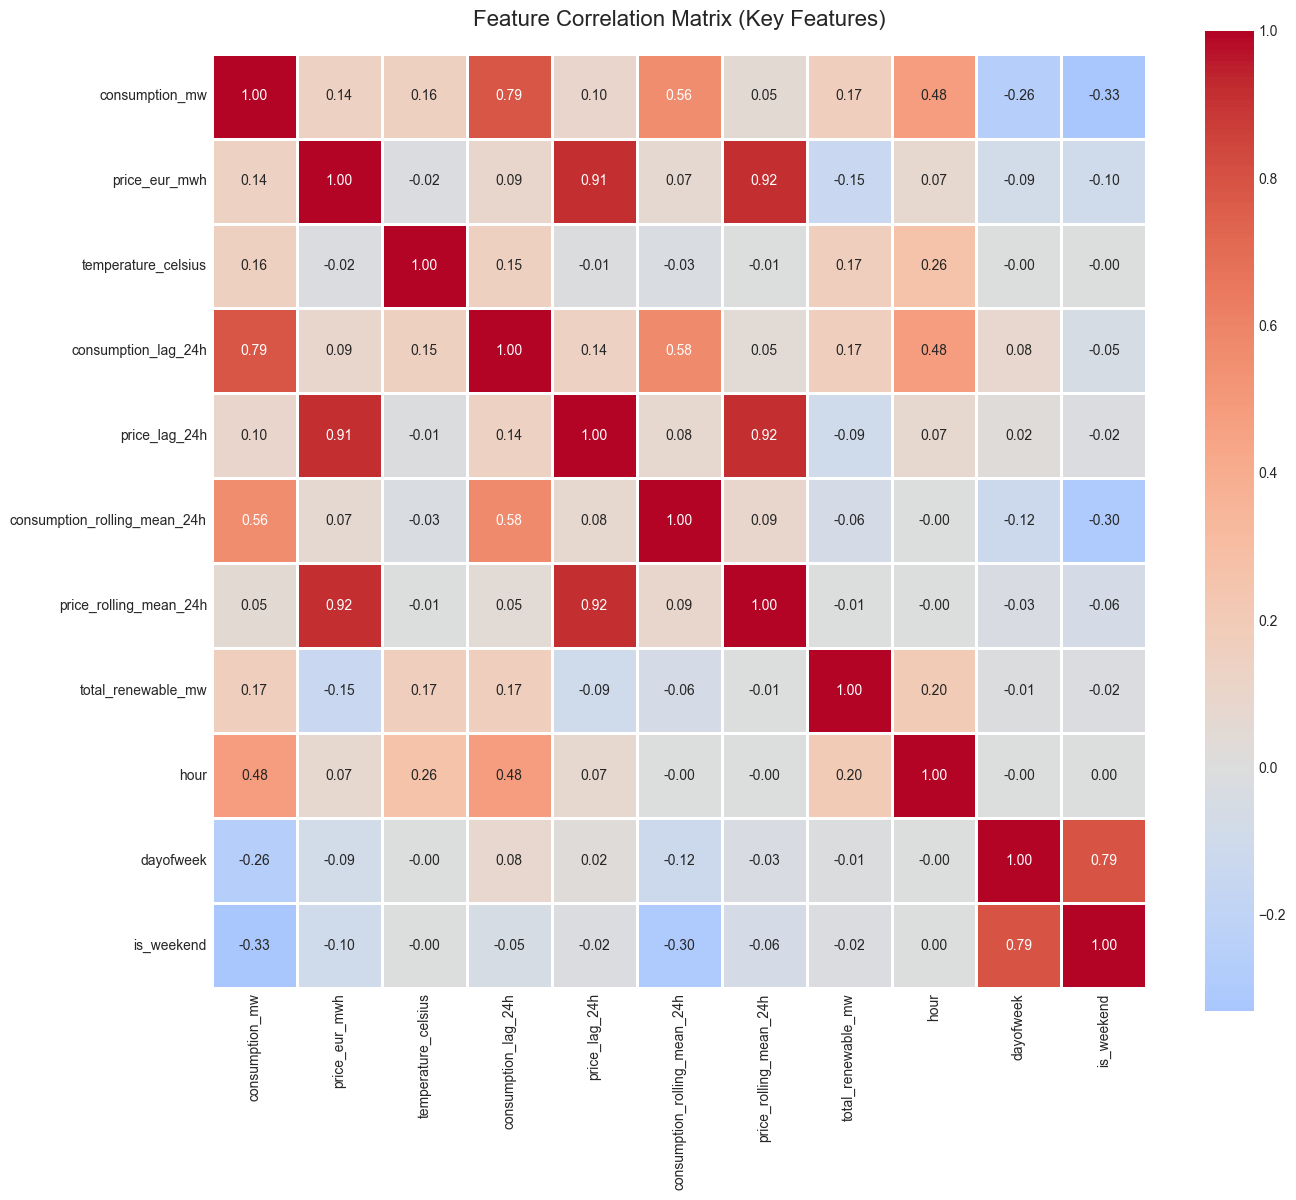

✓ Correlation plot saved to: ../outputs/plots/feature_correlations.png

📊 Top 10 Features Correlated with Consumption:
   2. consumption_lag_24h                      +0.785
   3. consumption_rolling_mean_24h             +0.561
   4. hour                                     +0.476
   5. total_renewable_mw                       +0.170
   6. temperature_celsius                      +0.156
   7. price_eur_mwh                            +0.137
   8. price_lag_24h                            +0.097
   9. price_rolling_mean_24h                   +0.049
  10. dayofweek                                -0.261
  11. is_weekend                               -0.331

📊 Top 10 Features Correlated with Price:
   2. price_rolling_mean_24h                   +0.916
   3. price_lag_24h                            +0.915
   4. consumption_mw                           +0.137
   5. consumption_lag_24h                      +0.092
   6. hour                                     +0.075
   7. consumption_rolling_mea

In [25]:
print("\n" + "=" * 80)
print("VISUALIZING FEATURE CORRELATIONS")
print("=" * 80)

# Select key features for visualization
key_features = [
    'consumption_mw',
    'price_eur_mwh',
    'temperature_celsius',
    'consumption_lag_24h',
    'price_lag_24h',
    'consumption_rolling_mean_24h',
    'price_rolling_mean_24h',
    'total_renewable_mw',
    'hour',
    'dayofweek',
    'is_weekend'
]

# Filter features that exist
available_features = [f for f in key_features if f in df.columns]

# Calculate correlation matrix
corr_matrix = df[available_features].corr()

# Plot
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix (Key Features)', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('outputs/plots/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Correlation plot saved to: ../outputs/plots/feature_correlations.png")

# Print top correlations with consumption
print(f"\n📊 Top 10 Features Correlated with Consumption:")
consumption_corr = corr_matrix['consumption_mw'].sort_values(ascending=False)
for i, (feature, corr) in enumerate(consumption_corr.head(11).items(), 1):
    if feature != 'consumption_mw':
        print(f"  {i:2d}. {feature:40s} {corr:+.3f}")

# Print top correlations with price
if 'price_eur_mwh' in available_features:
    print(f"\n📊 Top 10 Features Correlated with Price:")
    price_corr = corr_matrix['price_eur_mwh'].sort_values(ascending=False)
    for i, (feature, corr) in enumerate(price_corr.head(11).items(), 1):
        if feature != 'price_eur_mwh':
            print(f"  {i:2d}. {feature:40s} {corr:+.3f}")